[Home](../../README.md)

### Model Training - Random Forest Classifier

I have decided to use a random forest classifier for my model. 
A Random Forest Classifier builds multiple decision trees and combines their outputs to predict a class. I will train it to predict the `dominant_biome` of a Minecraft chunk based on the blocks in that chunk.

In [7]:
# Import frameworks
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from sklearn.ensemble import RandomForestClassifier
plt.style.use('../../style_Matplotlib_charts.mplstyle')

#### Load Training Data

Here I load the training CSV produced by `2.3.1.Split_Training_and_Testing_Data.ipynb` and check it with `.head()`.

In [8]:
# Load the training data
training_data = pd.read_csv("2.3.2.training_data.csv")

print(f"Shape: {training_data.shape}")
print(f'Biome classes found: {sorted(training_data["dominant_biome"].unique())}')
training_data.head()

Shape: (5860, 33)
Biome classes found: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]


,dominant_biome,air,dirt,water,short_grass,grass_block,sand,tall_seagrass,oak_leaves,birch_leaves,...,podzol,red_mushroom_block,mushroom_stem,poppy,coarse_dirt,oxeye_daisy,emerald_ore,lily_pad,snow,acacia_leaves
0,2,0.498310,0.543147,0.067489,0.175573,0.509514,0.000000,0.000000,0.076203,0.00000,...,0.0,0.5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,3,0.501462,0.648223,0.157254,0.022901,0.498943,0.000000,0.000000,0.934492,0.14916,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,5,0.492786,0.090863,0.453679,0.000000,0.000000,0.000000,0.543860,0.000000,0.00000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,5,0.492884,0.143655,0.308179,0.000000,0.000000,0.020144,0.263158,0.000000,0.00000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,7,0.496556,0.153299,0.094698,0.000000,0.000000,0.251799,0.228070,0.000000,0.00000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### Separate Features and Target

I'm spliiting the target, `dominant_biome` from all other columns, the features.

In [9]:
# Separate features and target
target_column = "dominant_biome"

X_train = training_data.drop(columns=[target_column])
y_train = training_data[target_column]

print(f"Features ({len(X_train.columns)}): {list(X_train.columns)}")
print(f"Training samples: {len(X_train)}")

Features (32): ['air', 'dirt', 'water', 'short_grass', 'grass_block', 'sand', 'tall_seagrass', 'oak_leaves', 'birch_leaves', 'oak_log', 'tall_grass', 'birch_log', 'kelp', 'kelp_plant', 'dark_oak_log', 'dark_oak_leaves', 'spruce_leaves', 'spruce_log', 'bush', 'sandstone', 'brown_mushroom', 'dandelion', 'podzol', 'red_mushroom_block', 'mushroom_stem', 'poppy', 'coarse_dirt', 'oxeye_daisy', 'emerald_ore', 'lily_pad', 'snow', 'acacia_leaves']
Training samples: 5860


#### Train the Classifier

I'm using a random forest model as my dataset has many features and requires a classification model that is efficient at handling that. I'm using `n_estimators` to select the number of decision trees and `random_state` to ensure predictable values, then training my model on my data.

In [10]:
# Train the Random Forest Classifier
model = RandomForestClassifier(n_estimators=500, random_state=15)
model.fit(X_train, y_train)

train_accuracy = model.score(X_train, y_train)
print(f"Training accuracy: {train_accuracy:.4f}")

Training accuracy: 1.0000


#### Step 5 - Feature Importance

I'm using a graph to visualise my most useful features for prediction. A higher score means that the block type was more useful in biome prediction.

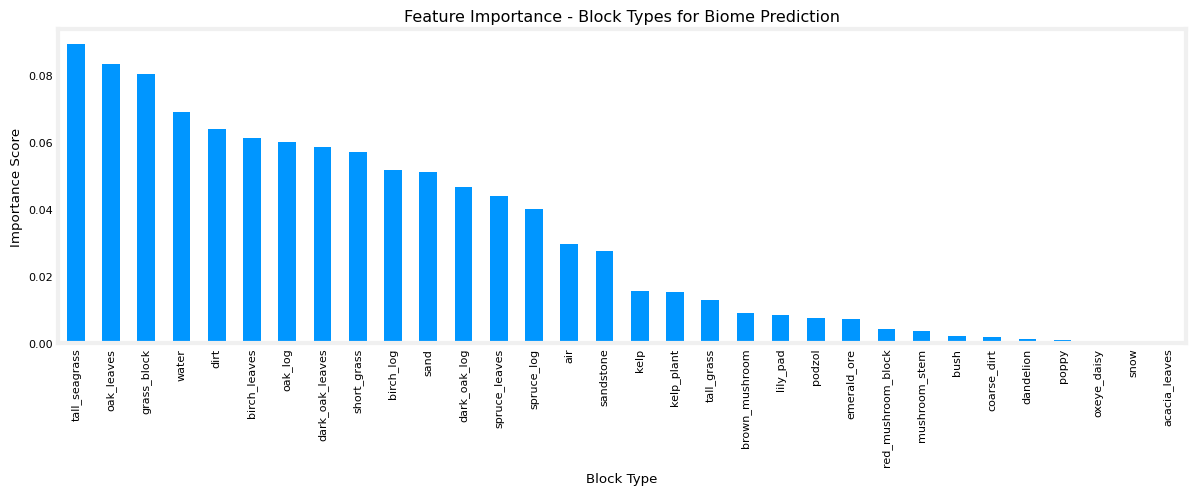

tall_seagrass         0.089071
oak_leaves            0.083313
grass_block           0.080069
water                 0.068747
dirt                  0.063750
birch_leaves          0.061010
oak_log               0.059839
dark_oak_leaves       0.058304
short_grass           0.057079
birch_log             0.051497
sand                  0.051012
dark_oak_log          0.046570
spruce_leaves         0.043897
spruce_log            0.040036
air                   0.029373
sandstone             0.027369
kelp                  0.015396
kelp_plant            0.015045
tall_grass            0.012643
brown_mushroom        0.008972
lily_pad              0.008302
podzol                0.007557
emerald_ore           0.007231
red_mushroom_block    0.004067
mushroom_stem         0.003454
bush                  0.002097
coarse_dirt           0.001755
dandelion             0.001090
poppy                 0.000960
oxeye_daisy           0.000247
snow                  0.000139
acacia_leaves         0.000107
dtype: f

In [11]:
# Plot feature importance
importances = pd.Series(model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(12, 5))
importances.plot(kind="bar")
plt.title("Feature Importance - Block Types for Biome Prediction")
plt.ylabel("Importance Score")
plt.xlabel("Block Type")
plt.tight_layout()
plt.show()

print(importances)

#### Step 6 - Save the Model

Finally, I'll save the trained model using `pickle` so it can be loaded and evaluated in `2.4.Model_Testing_and_Validation`.

In [12]:
# Save the trained model to the testing and validation folder
filename = "my_saved_model.sav"
pickle.dump(model, open("../2.4.Model_Testing_and_Validation/" + filename, "wb"))

print(f"Model saved as {filename}")

Model saved as my_saved_model.sav
